In [70]:
%load_ext autoreload
%autoreload 2
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from dstparser import parse_dst_file
from pathlib import Path
dst_dir = "/ceph/work/SATORI/projects/TA-ASIoP/tasdmc_dstbank/qgsii04proton/080417_160603/Em1_bsdinfo"
dst_file = Path(dst_dir)/"DAT000010_gea.rufldf.dst.gz"
data = parse_dst_file(dst_file)

In [3]:
for key in data:
    print(f"{key} {data[key].shape} {data[key].dtype}")

print(f"num_fields = {len(data)}")    

mass_number (187,) int32
energy (187,) float32
shower_axis (187, 3) float32
shower_core (187, 3) float32
std_recon_yymmdd (187,) float32
std_recon_hhmmss (187,) float32
std_recon_usec (187,) float32
std_recon_nofwf (187,) float32
std_recon_nsd (187,) float32
std_recon_nsclust (187,) float32
std_recon_nhits (187,) float32
std_recon_nborder (187,) float32
std_recon_qtot (187, 2) float32
std_recon_energy (187,) float32
std_recon_ldf_scale (187,) float32
std_recon_ldf_scale_err (187,) float32
std_recon_ldf_chi2 (187,) float32
std_recon_ldf_ndof (187,) float32
std_recon_shower_core (187, 2) float32
std_recon_shower_core_err (187, 2) float32
std_recon_s800 (187,) float32
std_recon_combined_energy (187,) float32
std_recon_combined_scale (187,) float32
std_recon_combined_scale_err (187,) float32
std_recon_combined_chi2 (187,) float32
std_recon_combined_ndof (187,) float32
std_recon_combined_shower_core (187, 2) float32
std_recon_combined_shower_core_err (187, 2) float32
std_recon_combined_s800

In [4]:
from dstparser.read_data import print_data_info
print_data_info(data)

mass_number.shape=(187,), dtype=int32, size=0.001 MB
energy.shape=(187,), dtype=float32, size=0.001 MB
shower_axis.shape=(187, 3), dtype=float32, size=0.002 MB
shower_core.shape=(187, 3), dtype=float32, size=0.002 MB
std_recon_yymmdd.shape=(187,), dtype=float32, size=0.001 MB
std_recon_hhmmss.shape=(187,), dtype=float32, size=0.001 MB
std_recon_usec.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nofwf.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nsd.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nsclust.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nhits.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nborder.shape=(187,), dtype=float32, size=0.001 MB
std_recon_qtot.shape=(187, 2), dtype=float32, size=0.001 MB
std_recon_energy.shape=(187,), dtype=float32, size=0.001 MB
std_recon_ldf_scale.shape=(187,), dtype=float32, size=0.001 MB
std_recon_ldf_scale_err.shape=(187,), dtype=float32, size=0.001 MB
std_recon_ldf_chi2.shape=(187,), dtype=float32, size=0.001

In [5]:
for key in data:
    if not key.startswith("std_recon"):
        print(f"{key} {data[key].shape} {data[key].dtype}")

mass_number (187,) int32
energy (187,) float32
shower_axis (187, 3) float32
shower_core (187, 3) float32
detector_positions (187, 7, 7, 3) float32
detector_positions_abs (187, 7, 7, 3) float32
detector_positions_id (187, 7, 7) float32
detector_states (187, 7, 7) bool
detector_exists (187, 7, 7) bool
detector_good (187, 7, 7) bool
nfold (187, 7, 7) float32
arrival_times (187, 7, 7) float32
time_traces (187, 7, 7, 128) float32
total_signals (187, 7, 7) float32


In [6]:
from dstparser.std_qcuts import std_spectrum_quality_cuts
qcut_mask = std_spectrum_quality_cuts(data)
qdata = {key : data[key][qcut_mask] for key in data}

Total = 187
cut                 : efficiency,  combined,      after cut
-----------------------------------------------------------
nsd                 :    96.26%,    96.26%,            180
zenith              :   100.00%,    96.26%,            180
dborder             :    75.40%,    74.33%,            139
tshape_border       :    98.93%,    73.26%,            137
point_dir           :    89.30%,    72.73%,            136
chi2_geom           :    98.40%,    72.73%,            136
chi2_ldf            :    94.65%,    72.19%,            135
s800_err            :    86.10%,    72.19%,            135


In [7]:
data = parse_dst_file(dst_file, ntile = 11, add_standard_recon=False, add_shower_params=False)

In [8]:
# This fails as standard reconstruction fields are not loaded
qcut_mask = std_spectrum_quality_cuts(data)

KeyError: 'std_recon_nsd'

In [10]:
for key in data:
    print(f"{key} {data[key].shape} {data[key].dtype}")
    
detector_fields = list(data.keys())    

detector_positions (187, 11, 11, 3) float32
detector_positions_abs (187, 11, 11, 3) float32
detector_positions_id (187, 11, 11) float32
detector_states (187, 11, 11) bool
detector_exists (187, 11, 11) bool
detector_good (187, 11, 11) bool
nfold (187, 11, 11) float32
arrival_times (187, 11, 11) float32
time_traces (187, 11, 11, 128) float32
total_signals (187, 11, 11) float32


In [23]:
detector_fields

['detector_positions',
 'detector_positions_abs',
 'detector_positions_id',
 'detector_states',
 'detector_exists',
 'detector_good',
 'nfold',
 'arrival_times',
 'time_traces',
 'total_signals']

In [26]:
data = parse_dst_file(dst_file, ntile = 11, avg_traces=False, add_standard_recon=False, add_shower_params=False)

for key in data:
        print(f"{key} {data[key].shape} {data[key].dtype}")

detector_positions (187, 11, 11, 3) float32
detector_positions_abs (187, 11, 11, 3) float32
detector_positions_id (187, 11, 11) float32
detector_states (187, 11, 11) bool
detector_exists (187, 11, 11) bool
detector_good (187, 11, 11) bool
nfold (187, 11, 11) float32
arrival_times_low (187, 11, 11) float32
arrival_times_up (187, 11, 11) float32
time_traces_low (187, 11, 11, 128) float32
time_traces_up (187, 11, 11, 128) float32
total_signals_low (187, 11, 11) float32
total_signals_up (187, 11, 11) float32


In [11]:
data = parse_dst_file(dst_file, ntile = 11, add_standard_recon=False)
for key in data:
    if key not in detector_fields:
        print(f"{key} {data[key].shape} {data[key].dtype}")  

mass_number (187,) int32
energy (187,) float32
shower_axis (187, 3) float32
shower_core (187, 3) float32


In [12]:
from dstparser.xmax_reader import XmaxReader
xmax_reader = XmaxReader(data_dir=dst_dir, glob_pattern="**/DAT*_xmax.txt", model="QGSJetII-04")

In [14]:
data = parse_dst_file(
    dst_file, ntile=11, add_standard_recon=False, xmax_reader=XmaxReader(dst_dir)
)

In [15]:
for key in data:
    if key not in detector_fields:
        print(f"{key} {data[key].shape} {data[key].dtype}")  

mass_number (187,) int32
energy (187,) float32
xmax (187,) float64
shower_axis (187, 3) float32
shower_core (187, 3) float32


In [16]:
data1 = parse_dst_file(dst_file, xmax_reader=XmaxReader(dst_dir, model="EPOS-LHC"))

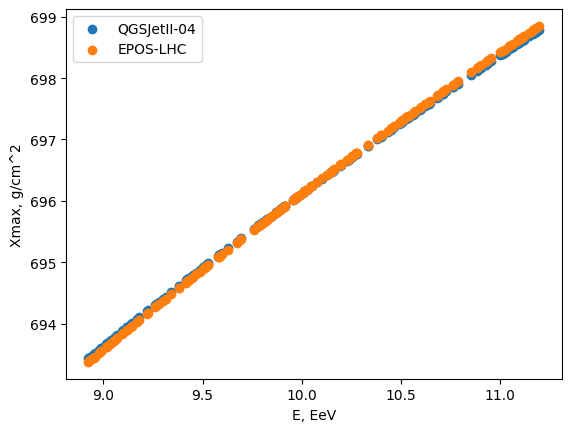

In [17]:
import matplotlib.pyplot as plt

data = parse_dst_file(dst_file, xmax_reader=XmaxReader(dst_dir, model="QGSJetII-04"))
plt.scatter(data["energy"], data["xmax"], label = "QGSJetII-04")
data = parse_dst_file(dst_file, xmax_reader=XmaxReader(dst_dir, model="EPOS-LHC"))
plt.scatter(data1["energy"], data1["xmax"], label = "EPOS-LHC")
plt.xlabel("E, EeV")
plt.ylabel("Xmax, g/cm^2")
plt.legend()

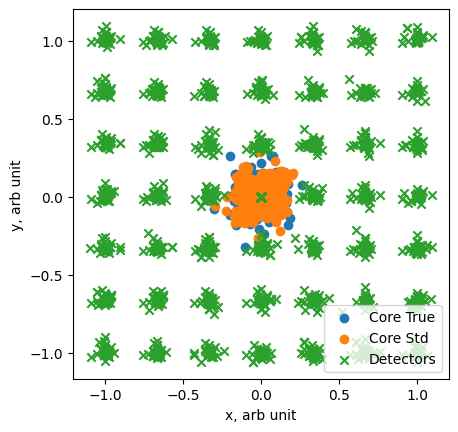

In [18]:
data = parse_dst_file(dst_file)
plt.scatter(data["shower_core"][:, 0], data["shower_core"][:, 1], label="Core True")
plt.scatter(data["std_recon_shower_core"][:, 0], data["std_recon_shower_core"][:, 1], label="Core Std")
plt.scatter(data["detector_positions"][..., 0], data["detector_positions"][..., 1], marker="x", label="Detectors")
plt.xlabel("x, arb unit")
plt.ylabel("y, arb unit")
plt.gca().set_aspect("equal")
plt.legend()

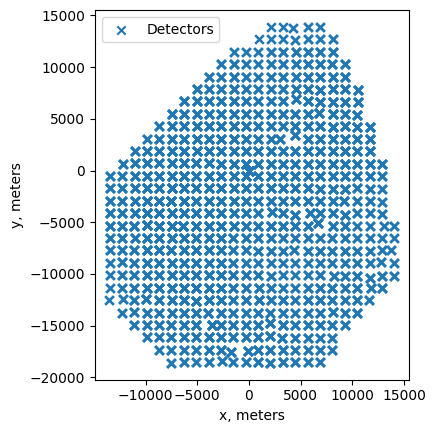

In [19]:
plt.scatter(data["detector_positions_abs"][..., 0], data["detector_positions_abs"][..., 1], marker="x", label="Detectors")
plt.xlabel("x, meters")
plt.ylabel("y, meters")
plt.gca().set_aspect("equal")
plt.legend()

In [ ]:
# TAx4 and TA files have slight difference
# parse_dst_file_tax4 reads TAx4 file and has the same functionality as parse_dst_file

# This fails as we have dst files for TA 
from dstparser import parse_dst_file_tax4
data = parse_dst_file_tax4(dst_file)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [29]:
glob_pattern = "DAT*dst.gz"
# Search for data files
dst_files = sorted([str(file) for file in Path(dst_dir).rglob(glob_pattern)])
print(f"Number of found data files = {len(dst_files)}")

Number of found data files = 33000


In [ ]:
acc_data = dict()
xmax_reader = XmaxReader(dst_dir)
for dst_file in dst_files[0:10]:
    data = parse_dst_file(
        dst_file,
        ntile=7,
        xmax_reader=xmax_reader,
        avg_traces=False,
        add_shower_params=True,
        add_standard_recon=False,
    )

    if data is None:
        continue

    for key, value in data.items():
        acc_data.setdefault(key, []).append(value)

In [46]:
from dstparser.read_data import print_data_info, read_hdf5_metadata
from dstparser.cli.io import save2hdf5, read_h5
import os

output_file = "/ceph/work/SATORI/antonpr/ml/benMC/sdanalysis_2019/handson/handson_new/outres.h5"

# Start with no compression
save2hdf5(
    acc_data,
    filename=output_file,
    compress_arrs=[]
)

In [47]:
read_hdf5_metadata(output_file)

{'file': '/ceph/work/SATORI/antonpr/ml/benMC/sdanalysis_2019/handson/handson_new/outres.h5',
 'arrival_times_low': {'shape': (1393, 7, 7)},
 'arrival_times_up': {'shape': (1393, 7, 7)},
 'detector_exists': {'shape': (1393, 7, 7)},
 'detector_good': {'shape': (1393, 7, 7)},
 'detector_positions': {'shape': (1393, 7, 7, 3)},
 'detector_positions_abs': {'shape': (1393, 7, 7, 3)},
 'detector_positions_id': {'shape': (1393, 7, 7)},
 'detector_states': {'shape': (1393, 7, 7)},
 'energy': {'shape': (1393,)},
 'mass_number': {'shape': (1393,)},
 'nfold': {'shape': (1393, 7, 7)},
 'shower_axis': {'shape': (1393, 3)},
 'shower_core': {'shape': (1393, 3)},
 'time_traces_low': {'shape': (1393, 7, 7, 128)},
 'time_traces_up': {'shape': (1393, 7, 7, 128)},
 'total_signals_low': {'shape': (1393, 7, 7)},
 'total_signals_up': {'shape': (1393, 7, 7)},
 'xmax': {'shape': (1393,)}}

In [48]:
print(f"The size of '{output_file}' is: {os.path.getsize(output_file)/1024**2:.2f} Mb.")

The size of '/ceph/work/SATORI/antonpr/ml/benMC/sdanalysis_2019/handson/handson_new/outres.h5' is: 70.03 Mb.


In [49]:
# With compression
save2hdf5(
    acc_data,
    filename=output_file,
    compress_arrs=["time", "arrival", "detector"],
)

read_hdf5_metadata(output_file)

{'file': '/ceph/work/SATORI/antonpr/ml/benMC/sdanalysis_2019/handson/handson_new/outres.h5',
 'arrival_times_low/ic_data': {'shape': (4541,)},
 'arrival_times_low/ic_idxs': {'shape': (4541,)},
 'arrival_times_low/ic_info': {'shape': (2,)},
 'arrival_times_low/nz_data': {'shape': (8817,)},
 'arrival_times_low/shape': {'shape': (3,)},
 'arrival_times_up/ic_data': {'shape': (4541,)},
 'arrival_times_up/ic_idxs': {'shape': (4541,)},
 'arrival_times_up/ic_info': {'shape': (2,)},
 'arrival_times_up/nz_data': {'shape': (8817,)},
 'arrival_times_up/shape': {'shape': (3,)},
 'detector_exists': {'shape': (1393, 7, 7)},
 'detector_good': {'shape': (1393, 7, 7)},
 'detector_positions/ic_data': {'shape': (4740,)},
 'detector_positions/ic_idxs': {'shape': (4740,)},
 'detector_positions/ic_info': {'shape': (2,)},
 'detector_positions/nz_data': {'shape': (176121,)},
 'detector_positions/shape': {'shape': (4,)},
 'detector_positions_abs/ic_data': {'shape': (2416,)},
 'detector_positions_abs/ic_idxs': {

In [50]:
print(f"The size of '{output_file}' is: {os.path.getsize(output_file)/1024**2:.2f} Mb.")

The size of '/ceph/work/SATORI/antonpr/ml/benMC/sdanalysis_2019/handson/handson_new/outres.h5' is: 12.02 Mb.


In [53]:
data_from_h5 = read_h5(output_file)
print_data_info(data_from_h5)

arrival_times_low.shape=(1393, 7, 7), dtype=float32, size=0.260 MB
arrival_times_up.shape=(1393, 7, 7), dtype=float32, size=0.260 MB
detector_exists.shape=(1393, 7, 7), dtype=float32, size=0.260 MB
detector_good.shape=(1393, 7, 7), dtype=float32, size=0.260 MB
detector_positions.shape=(1393, 7, 7, 3), dtype=float32, size=0.781 MB
detector_positions_abs.shape=(1393, 7, 7, 3), dtype=float32, size=0.781 MB
detector_positions_id.shape=(1393, 7, 7), dtype=float32, size=0.260 MB
detector_states.shape=(1393, 7, 7), dtype=float32, size=0.260 MB
energy.shape=(1393,), dtype=float32, size=0.005 MB
mass_number.shape=(1393,), dtype=int32, size=0.005 MB
nfold.shape=(1393, 7, 7), dtype=float32, size=0.260 MB
shower_axis.shape=(1393, 3), dtype=float32, size=0.016 MB
shower_core.shape=(1393, 3), dtype=float32, size=0.016 MB
time_traces_low.shape=(1393, 7, 7, 128), dtype=float32, size=33.329 MB
time_traces_up.shape=(1393, 7, 7, 128), dtype=float32, size=33.329 MB
total_signals_low.shape=(1393, 7, 7), dt

In [55]:
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")

acc_data1 = dict()
for dst_file in tqdm(dst_files, total=len(dst_files)):
    data = parse_dst_file(
        dst_file,
        ntile=7,
        xmax_reader=XmaxReader(dst_dir),
        avg_traces=False,
        add_shower_params=True,
        add_standard_recon=False,
    )

    if data is None:
        continue

    for key, value in data.items():
        acc_data1.setdefault(key, []).append(value)

  0%|          | 0/33000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [205]:
from dstparser import parse_dst_file_vlen
from pathlib import Path
dst_dir = "/ceph/work/SATORI/projects/TA-ASIoP/tasdmc_dstbank/qgsii04proton/080417_160603/Em1_bsdinfo"
dst_file = Path(dst_dir)/"DAT000010_gea.rufldf.dst.gz"
data_vlen = parse_dst_file_vlen(dst_file)

Missmatch between hits and waveforms in:
  /ceph/work/SATORI/projects/TA-ASIoP/tasdmc_dstbank/qgsii04proton/080417_160603/Em1_bsdinfo/DAT000010_gea.rufldf.dst.gz
  with n=24 waveform out of 7125 not corresonding to any hit (0.336842%)


In [206]:
data = parse_dst_file(dst_file)
print_data_info(data)

mass_number.shape=(187,), dtype=int32, size=0.001 MB
energy.shape=(187,), dtype=float32, size=0.001 MB
shower_axis.shape=(187, 3), dtype=float32, size=0.002 MB
shower_core.shape=(187, 3), dtype=float32, size=0.002 MB
std_recon_yymmdd.shape=(187,), dtype=float32, size=0.001 MB
std_recon_hhmmss.shape=(187,), dtype=float32, size=0.001 MB
std_recon_usec.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nofwf.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nsd.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nsclust.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nhits.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nborder.shape=(187,), dtype=float32, size=0.001 MB
std_recon_qtot.shape=(187, 2), dtype=float32, size=0.001 MB
std_recon_energy.shape=(187,), dtype=float32, size=0.001 MB
std_recon_ldf_scale.shape=(187,), dtype=float32, size=0.001 MB
std_recon_ldf_scale_err.shape=(187,), dtype=float32, size=0.001 MB
std_recon_ldf_chi2.shape=(187,), dtype=float32, size=0.001

In [207]:
data_vlen = parse_dst_file_vlen(dst_file)
print_data_info(data_vlen)

Missmatch between hits and waveforms in:
  /ceph/work/SATORI/projects/TA-ASIoP/tasdmc_dstbank/qgsii04proton/080417_160603/Em1_bsdinfo/DAT000010_gea.rufldf.dst.gz
  with n=24 waveform out of 7125 not corresonding to any hit (0.336842%)
mass_number.shape=(187,), dtype=int32, size=0.001 MB
energy.shape=(187,), dtype=float64, size=0.001 MB
shower_axis.shape=(187, 3), dtype=float64, size=0.004 MB
shower_core.shape=(187, 3), dtype=float64, size=0.004 MB
std_recon_yymmdd.shape=(187,), dtype=int64, size=0.001 MB
std_recon_hhmmss.shape=(187,), dtype=int64, size=0.001 MB
std_recon_usec.shape=(187,), dtype=int64, size=0.001 MB
std_recon_nofwf.shape=(187,), dtype=int32, size=0.001 MB
std_recon_nsd.shape=(187,), dtype=int32, size=0.001 MB
std_recon_nsclust.shape=(187,), dtype=int32, size=0.001 MB
std_recon_nhits.shape=(187,), dtype=int32, size=0.001 MB
std_recon_nborder.shape=(187,), dtype=float64, size=0.001 MB
std_recon_qtot.shape=(187, 2), dtype=float64, size=0.003 MB
std_recon_energy.shape=(187

In [208]:
data_vlen = parse_dst_file_vlen(dst_file, add_shower_params=False, add_standard_recon=False)
print_data_info(data_vlen)

Missmatch between hits and waveforms in:
  /ceph/work/SATORI/projects/TA-ASIoP/tasdmc_dstbank/qgsii04proton/080417_160603/Em1_bsdinfo/DAT000010_gea.rufldf.dst.gz
  with n=24 waveform out of 7125 not corresonding to any hit (0.336842%)
arrival_times.shape=(1726, 2), dtype=float64, size=0.026 MB
pulse_area.shape=(1726, 2), dtype=float64, size=0.026 MB
detector_positions.shape=(1726, 3), dtype=float64, size=0.040 MB
status.shape=(1726,), dtype=int32, size=0.007 MB
nfold.shape=(1726,), dtype=int32, size=0.007 MB
detector_ids.shape=(1726,), dtype=int32, size=0.007 MB
hit_offsets.shape=(188,), dtype=int64, size=0.001 MB
hit_tt_offsets.shape=(1727,), dtype=int64, size=0.013 MB
time_traces.shape=(2246, 2, 128), dtype=float32, size=2.193 MB
tt_offsets.shape=(188,), dtype=int64, size=0.001 MB
---
Total size = 2.32 MB



In [209]:
data = parse_dst_file_vlen(dst_file)
evt_idx = 20
hits_start = data["hit_offsets"][evt_idx]
hits_end = data["hit_offsets"][evt_idx+1]
data["pulse_area"][hits_start:hits_end].shape

Missmatch between hits and waveforms in:
  /ceph/work/SATORI/projects/TA-ASIoP/tasdmc_dstbank/qgsii04proton/080417_160603/Em1_bsdinfo/DAT000010_gea.rufldf.dst.gz
  with n=24 waveform out of 7125 not corresonding to any hit (0.336842%)


(13, 2)

In [210]:
dst_file = Path(dst_dir)/"DAT005020_gea.rufldf.dst.gz"
data = parse_dst_file_vlen(dst_file)

event_lens = np.diff(data["hit_offsets"])

for evt_idx, num_hits in enumerate(event_lens[0:10]):
    start = data["hit_offsets"][evt_idx]
    end = data["hit_offsets"][evt_idx+1]
    num_unique_det = len(np.unique(data["detector_ids"][start:end]))
    
    # if num_unique_det != num_hits:
    print(f"id={evt_idx}, num hits={num_hits}, num unique detectors={num_unique_det}")

id=0, num hits=19, num unique detectors=19
id=1, num hits=8, num unique detectors=8
id=2, num hits=11, num unique detectors=11
id=3, num hits=23, num unique detectors=23
id=4, num hits=9, num unique detectors=9
id=5, num hits=22, num unique detectors=22
id=6, num hits=23, num unique detectors=23
id=7, num hits=29, num unique detectors=29
id=8, num hits=18, num unique detectors=18
id=9, num hits=23, num unique detectors=23


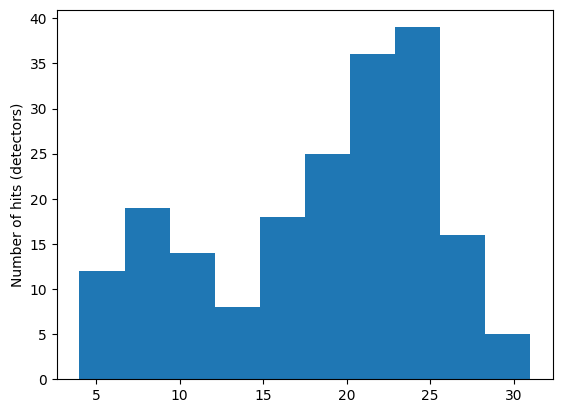

In [223]:
_ = plt.hist(event_lens)
plt.ylabel("Number of hits (detectors)")
plt.show()

In [212]:
evt_idx = 9
hits_start = data["hit_offsets"][evt_idx]
hits_end = data["hit_offsets"][evt_idx+1]

# Per-event time-trace slice
tt_start = data["hit_tt_offsets"][hits_start]
tt_end = data["hit_tt_offsets"][hits_end]

ttrace = data["time_traces"][tt_start:tt_end]
ttrace.shape

(39, 2, 128)

In [213]:
nfolds = data["nfold"][hits_start:hits_end]
np.sum(nfolds)

np.int64(39)

In [214]:
windows_offsets = np.cumsum([0] + nfolds)

In [215]:
split_ttraces =np.split(ttrace, windows_offsets[1:-1])

In [216]:
split_ttraces[0].shape

(2, 2, 128)

In [220]:
hh = split_ttraces[0].transpose(1, 0, 2).reshape(2, -1)

In [222]:
len(split_ttraces)

22

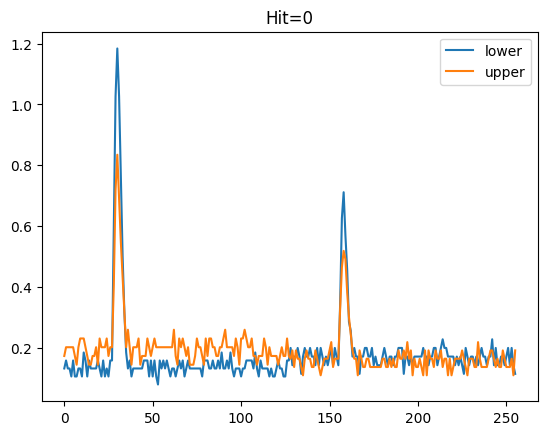

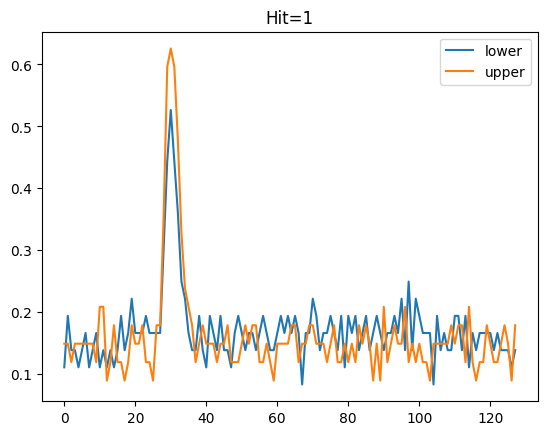

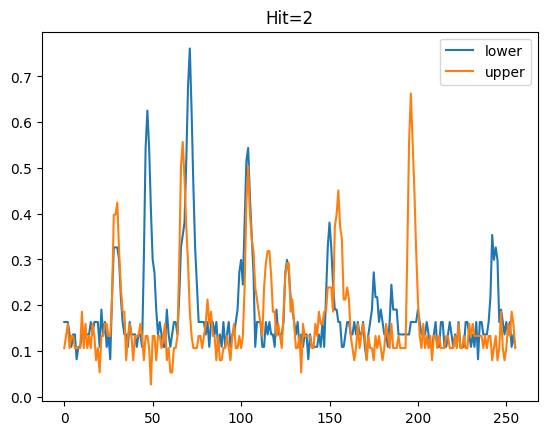

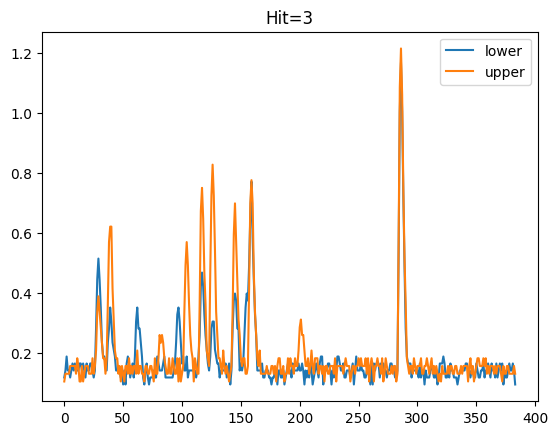

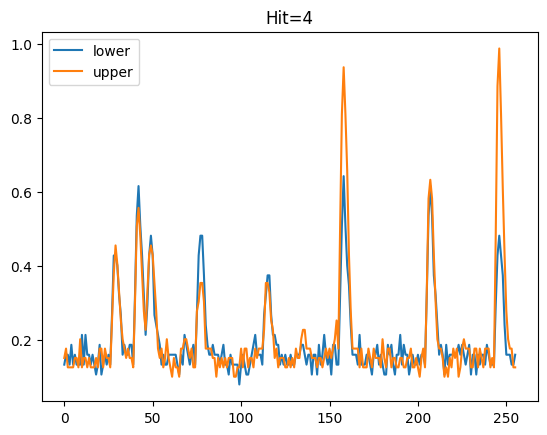

In [218]:
for ihit in range(len(split_ttraces[0:5])):
    joined_ttraces = split_ttraces[ihit].transpose(1, 0, 2).reshape(2, -1)
    plt.plot(joined_ttraces[0], label = "lower")
    plt.plot(joined_ttraces[1], label = "upper")
    plt.title(f"Hit={ihit}")
    plt.legend()
    plt.show()

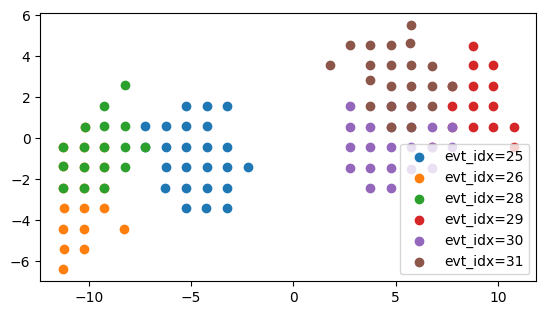

In [156]:
for evt_idx in [25, 26, 28, 29, 30, 31]:
    hits_start = data["hit_offsets"][evt_idx]
    hits_end = data["hit_offsets"][evt_idx+1]
    det_pos = data["detector_positions"][hits_start:hits_end]
    plt.scatter(det_pos[:,0], det_pos[:,1], label = f"evt_idx={evt_idx}")
    plt.legend()
plt.gca().set_aspect("equal")    

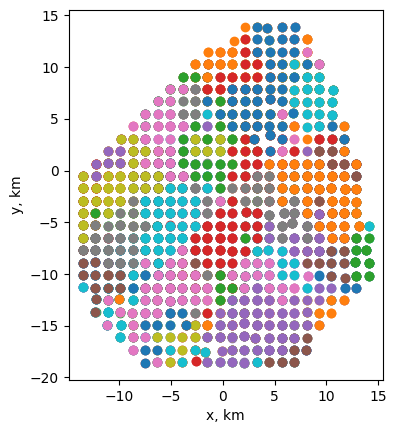

In [159]:
for evt_idx in range(data["hit_offsets"].shape[0]-1):
    hits_start = data["hit_offsets"][evt_idx]
    hits_end = data["hit_offsets"][evt_idx+1]
    det_pos = data["detector_positions"][hits_start:hits_end]*1200/1000
    plt.scatter(det_pos[:,0], det_pos[:,1])
    plt.xlabel("x, km")
    plt.ylabel("y, km")
plt.gca().set_aspect("equal")

In [ ]:
# In vlen version 
# pulse_area[...,0] corresponds to "total_signals_low" 
# pulse_area[...,1] corresponds to "total_signals_up" 

In [160]:
import h5py
from dstparser import append_to_hdf5

acc_data = dict()
xmax_reader = XmaxReader(dst_dir)
output_file = "/ceph/work/SATORI/antonpr/ml/benMC/sdanalysis_2019/handson/handson_new/vlen_outres.h5"

with h5py.File(output_file, "a") as f:
    for dst_file in dst_files[0:10]:
        data = parse_dst_file_vlen(
            dst_file,
            xmax_reader=xmax_reader,
            add_shower_params=True,
            add_standard_recon=True,
        )

        if data is None:
            continue

        for key, value in data.items():
            acc_data.setdefault(key, []).append(value)
            
        append_to_hdf5(f, data)    

In [161]:
read_hdf5_metadata(output_file)

{'file': '/ceph/work/SATORI/antonpr/ml/benMC/sdanalysis_2019/handson/handson_new/vlen_outres.h5',
 'arrival_times': {'shape': (9065, 2)},
 'detector_ids': {'shape': (9065,)},
 'detector_positions': {'shape': (9065, 3)},
 'energy': {'shape': (1393,)},
 'hit_offsets': {'shape': (1394,)},
 'hit_tt_offsets': {'shape': (9066,)},
 'mass_number': {'shape': (1393,)},
 'nfold': {'shape': (9065,)},
 'pulse_area': {'shape': (9065, 2)},
 'shower_axis': {'shape': (1393, 3)},
 'shower_core': {'shape': (1393, 3)},
 'status': {'shape': (9065,)},
 'std_recon_border_distance': {'shape': (1393,)},
 'std_recon_border_distance_tshape': {'shape': (1393,)},
 'std_recon_curvature': {'shape': (1393,)},
 'std_recon_curvature_err': {'shape': (1393,)},
 'std_recon_energy': {'shape': (1393,)},
 'std_recon_geom_chi2': {'shape': (1393,)},
 'std_recon_geom_ndof': {'shape': (1393,)},
 'std_recon_hhmmss': {'shape': (1393,)},
 'std_recon_ldf_chi2': {'shape': (1393,)},
 'std_recon_ldf_ndof': {'shape': (1393,)},
 'std_rec

In [162]:
print(f"The size of '{output_file}' is: {os.path.getsize(output_file)/1024**2:.2f} Mb.")

The size of '/ceph/work/SATORI/antonpr/ml/benMC/sdanalysis_2019/handson/handson_new/vlen_outres.h5' is: 11.37 Mb.


In [163]:
from dstparser import H5DST, MultiH5DST

In [164]:
rdata_vlen = H5DST(output_file)

In [196]:
for field in rdata_vlen.keys():
    print(field)

arrival_times
detector_ids
detector_positions
energy
hit_offsets
hit_tt_offsets
mass_number
nfold
pulse_area
shower_axis
shower_core
status
std_recon_border_distance
std_recon_border_distance_tshape
std_recon_curvature
std_recon_curvature_err
std_recon_energy
std_recon_geom_chi2
std_recon_geom_ndof
std_recon_hhmmss
std_recon_ldf_chi2
std_recon_ldf_ndof
std_recon_ldf_scale
std_recon_ldf_scale_err
std_recon_nborder
std_recon_nhits
std_recon_nofwf
std_recon_nsclust
std_recon_nsd
std_recon_qtot
std_recon_s800
std_recon_shower_axis
std_recon_shower_axis_err
std_recon_shower_core
std_recon_shower_core_err
std_recon_usec
std_recon_yymmdd
time_traces
tt_offsets
xmax


In [203]:
type(rdata_vlen["energy"]), rdata_vlen["energy"].shape

(h5py._hl.dataset.Dataset, (1393,))

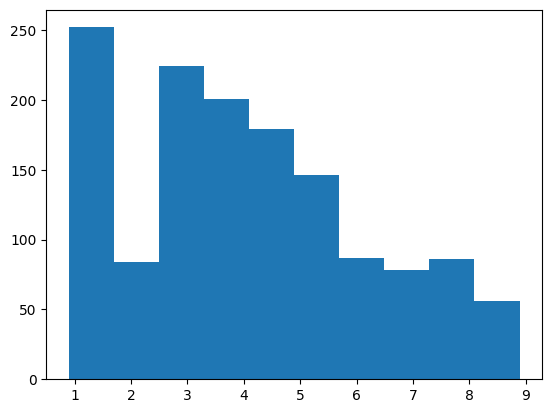

In [ ]:
_ =plt.hist(rdata_vlen["energy"])

In [189]:
evt_idx = 1392
nhits = len(rdata_vlen["time_traces"][evt_idx])
print(nhits)

5


In [191]:
hit_idx = 2
rdata_vlen["time_traces"][evt_idx, hit_idx].shape

(3, 2, 128)

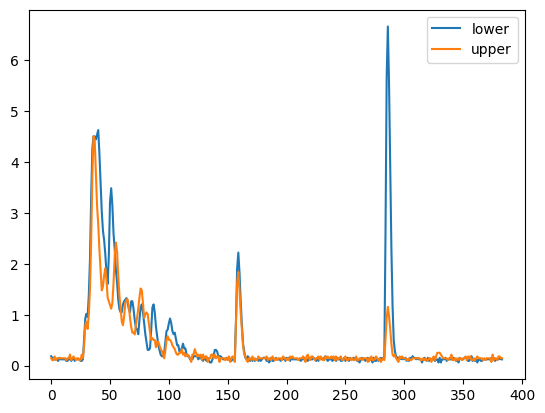

In [ ]:
evt_idx = 1392
hit_idx = 2

tt = rdata_vlen["time_traces"][evt_idx, hit_idx]
joined_ttraces = tt.transpose(1, 0, 2).reshape(2, -1)
plt.plot(joined_ttraces[0], label = "lower")
plt.plot(joined_ttraces[1], label = "upper")
plt.legend()